# Plotting predictions, slopes, and contrasts

The `smmargins.plot` subpackage renders three families of curves:

- `plot_predictions` — the predicted response across a covariate.
- `plot_slopes` — marginal effects across a covariate.
- `plot_comparisons` — contrasts (factor levels or unit steps) across a covariate.

All three accept the same inference kwargs as the underlying `predict` / `dydx` / `contrast` calls (`vce=`, `cov_type=`, `ci_method=`), so simultaneous confidence bands, robust covariance, and bootstrap SEs are one kwarg away.

## When to reach for plotting

Tables of marginal effects answer *what is the effect at $x = 0$?* Plots answer *how does the effect change as $x$ moves?* — the question that motivates marginal-effects analysis in the first place. Use the plot functions when you want to *see* heterogeneity, monotonicity, or non-linearity, not just summarise it.

## Setup

We simulate a logit with two continuous covariates and a categorical group, then fit it with statsmodels.

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

from smmargins import Margins
from smmargins.plot import plot_predictions, plot_slopes, plot_comparisons

rng = np.random.default_rng(0)
n = 500
df = pd.DataFrame({
    "x1": rng.standard_normal(n),
    "x2": rng.standard_normal(n),
    "grp": rng.choice(["a", "b", "c"], size=n),
})
eta = 0.5 + 1.2 * df["x1"] - 0.7 * df["x2"] + (df["grp"] == "b") * 0.5
df["y"] = (rng.uniform(size=n) < 1 / (1 + np.exp(-eta))).astype(int)

fit = smf.logit("y ~ x1 + x2 + C(grp)", data=df).fit(disp=False)
M = Margins(fit)
fit.params

Intercept      0.551389
C(grp)[T.b]    0.624688
C(grp)[T.c]   -0.165512
x1             1.389431
x2            -0.623718
dtype: float64

## Predictions across a covariate

The simplest call: pass the variable name as `condition`. `smmargins` builds a 50-point linspace over the observed range and computes the average predicted probability at each grid point, with a 95% pointwise CI.

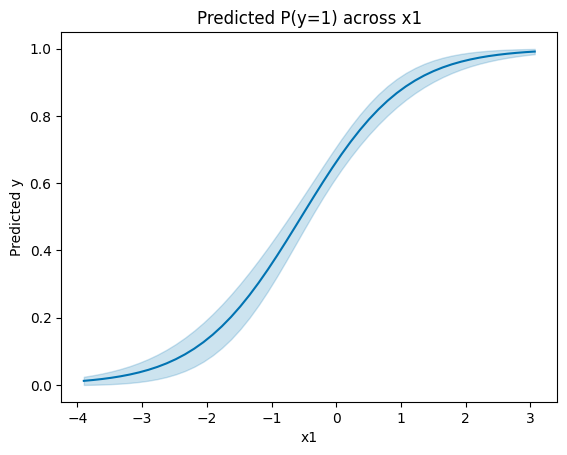

In [2]:
fig, ax = plot_predictions(M, "x1")
ax.set_title("Predicted P(y=1) across x1");

### Faceting with `by=`

Pass a categorical column to `by=` to render one line per level.

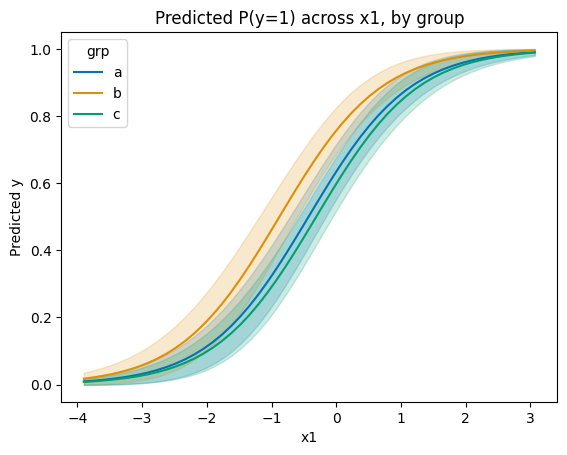

In [3]:
fig, ax = plot_predictions(M, "x1", by="grp")
ax.set_title("Predicted P(y=1) across x1, by group");

### Custom grids

If the auto-grid isn't right (e.g. you want denser sampling near zero, or to extrapolate past the observed range), pass a dict for `condition`:

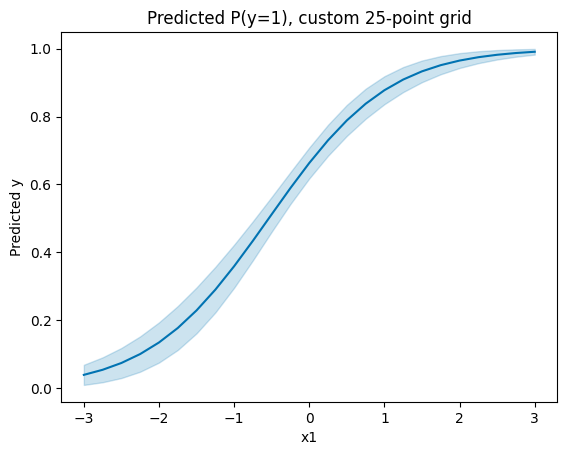

In [4]:
fig, ax = plot_predictions(M, {"x1": np.linspace(-3, 3, 25)})
ax.set_title("Predicted P(y=1), custom 25-point grid");

## Simultaneous confidence bands

The default CI is **pointwise**: each x-point's interval has 95% coverage on its own, but the band as a whole does not. For inference about the curve ("is the predicted probability ever above 0.7?"), you need a **simultaneous** band.

`ci_method="bonferroni"` and `ci_method="sidak"` work with any VCE. `ci_method="sup-t"` is tighter but requires a draw-based VCE (`vce="simulation"` or `vce="bootstrap"`).

This is the main differentiator vs `marginaleffects`'s plotting — surface it explicitly.

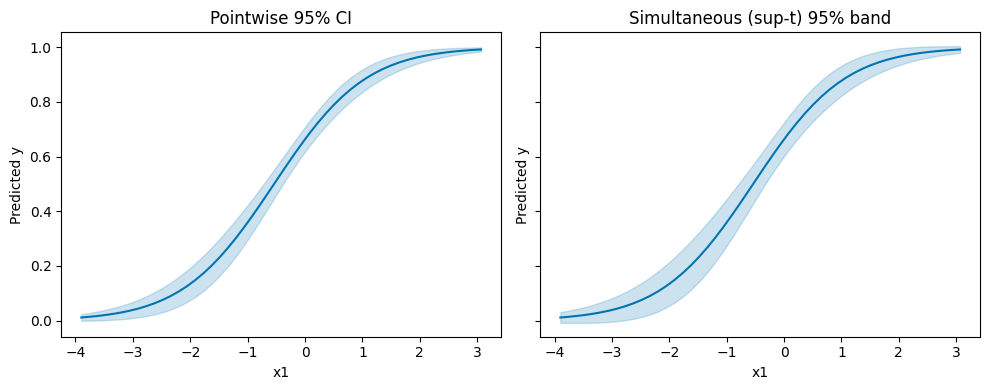

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
plot_predictions(M, "x1", ax=axes[0])
axes[0].set_title("Pointwise 95% CI")
plot_predictions(
    M, "x1",
    vce="simulation", n_sims=2000, sim_seed=0,
    ci_method="sup-t",
    ax=axes[1],
)
axes[1].set_title("Simultaneous (sup-t) 95% band")
fig.tight_layout();

The sup-t band is wider than the pointwise band by construction — that's the point. Anywhere the pointwise band excludes a value but the simultaneous band does not, the pointwise inference would be misleading if you intend to make claims about the *curve*.

## Marginal effects: `plot_slopes`

Slopes (i.e. `dydx`) across a covariate. Pass the variable whose slope you want and the conditioning variable.

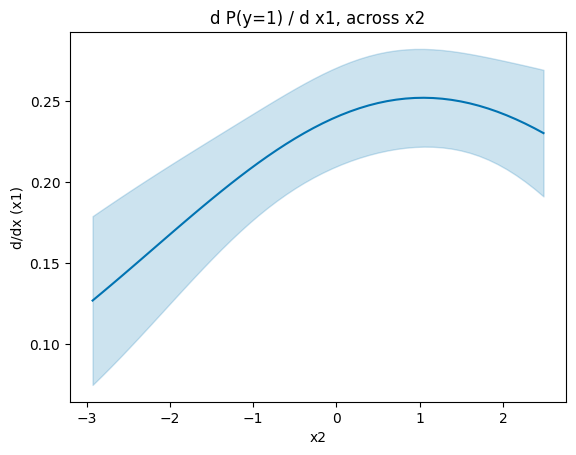

In [6]:
fig, ax = plot_slopes(M, "x1", "x2")
ax.set_title("d P(y=1) / d x1, across x2");

## Contrasts: `plot_comparisons`

For a binary or factor variable, `plot_comparisons` shows the contrast (level vs reference, or unit step for numerics) across a conditioning variable. Internally it calls `Margins.contrast` and reads the joint-SE difference row, so the band is the *correct* SE — not the naïve sum of variances.

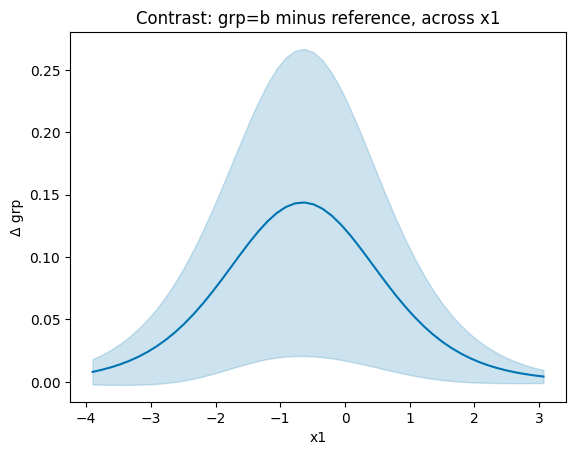

In [7]:
# Compare grp='b' vs reference across x1.
fig, ax = plot_comparisons(M, "grp", condition="x1")
ax.set_title("Contrast: grp=b minus reference, across x1");

## Pitfalls

- **`ci_method="sup-t"` without a draw-based VCE raises.** The sup-t band needs the joint draw matrix; pointwise SEs alone aren'"'"'t enough.
- **`backend="plotly"` raises `NotImplementedError`** in 0.5; the dispatch entry exists but the implementation is planned for 0.6.
- **Auto-grids extrapolate to the full observed range.** For heavy-tailed covariates, the predicted curve at the extremes can be unreliable. Pass a dict for `condition` if you want to constrain the grid.
- **Multi-output models** (MNLogit, OrderedModel) plot one line per outcome by default. Use `outcome=` to pick a single outcome.

## See also

- API: `smmargins.plot.plot_predictions`, `smmargins.plot.plot_slopes`, `smmargins.plot.plot_comparisons` — see the reference page.
- Explanation: {doc}`/explanations/contrast_joint_covariance` — why `plot_comparisons` uses joint SEs instead of naïve summed variances.
- Tutorial: `values_dsl.ipynb` (forthcoming) — the per-variable DSL underlying every plot'"'"'s grid spec.
